Device: cuda
Training ResNet
[ResNet] Epoch 01 | Loss: 1.409 | Train Acc: 49.0%
[ResNet] Epoch 02 | Loss: 1.035 | Train Acc: 63.2%
[ResNet] Epoch 03 | Loss: 0.885 | Train Acc: 68.8%
[ResNet] Epoch 04 | Loss: 0.794 | Train Acc: 72.1%
[ResNet] Epoch 05 | Loss: 0.725 | Train Acc: 74.7%
[ResNet] Epoch 06 | Loss: 0.677 | Train Acc: 76.5%
[ResNet] Epoch 07 | Loss: 0.628 | Train Acc: 78.2%
[ResNet] Epoch 08 | Loss: 0.595 | Train Acc: 79.4%
[ResNet] Epoch 09 | Loss: 0.561 | Train Acc: 80.6%
[ResNet] Epoch 10 | Loss: 0.536 | Train Acc: 81.5%

[ResNet] ✅ Final Test Accuracy: 80.22%

Training AlexNet
[AlexNet] Epoch 01 | Loss: 1.771 | Train Acc: 33.2%
[AlexNet] Epoch 02 | Loss: 1.391 | Train Acc: 49.2%
[AlexNet] Epoch 03 | Loss: 1.236 | Train Acc: 55.6%
[AlexNet] Epoch 04 | Loss: 1.127 | Train Acc: 59.9%
[AlexNet] Epoch 05 | Loss: 1.033 | Train Acc: 63.7%
[AlexNet] Epoch 06 | Loss: 0.960 | Train Acc: 66.5%
[AlexNet] Epoch 07 | Loss: 0.900 | Train Acc: 68.6%
[AlexNet] Epoch 08 | Loss: 0.872 | Trai

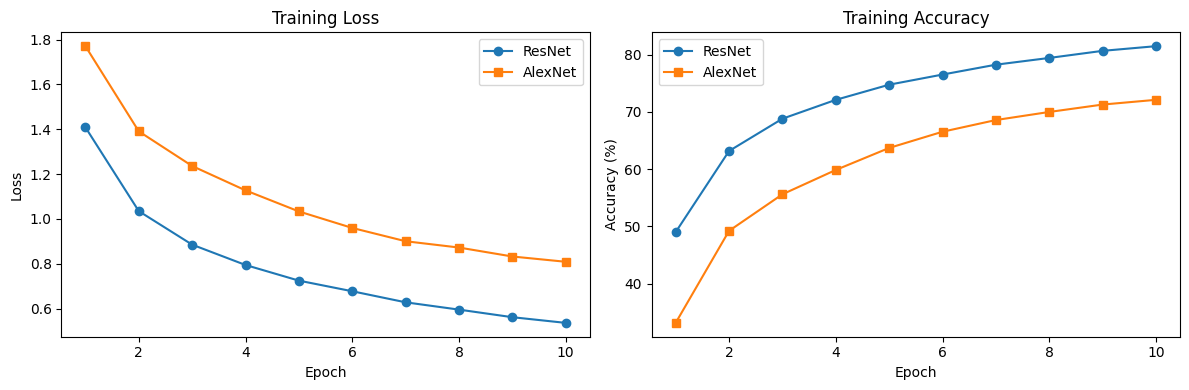


ResNet  Test Acc: 80.22%
AlexNet Test Acc: 73.44%


In [7]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ── Data ──────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64, shuffle=False)

# ── AlexNet ───────────────────────────────────────
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(64, 192, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(192, 384, 3, padding=1), nn.ReLU(),
            nn.Conv2d(384, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(256*4*4, 4096), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(4096, 4096), nn.ReLU(),
            nn.Linear(4096, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1))

# ── ResNet ────────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.block(x) + x)

class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1  = nn.Sequential(nn.Conv2d(3,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU())
        self.layer1 = ResidualBlock(64)
        self.layer2 = ResidualBlock(64)
        self.layer3 = ResidualBlock(64)
        self.pool   = nn.AdaptiveAvgPool2d((4,4))
        self.fc     = nn.Linear(64*4*4, num_classes)
    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        return self.fc(x.view(x.size(0), -1))

# ── Train & Evaluate ──────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

def evaluate(model):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in testloader:
            imgs, labels = imgs.to(device), labels.to(device)
            _, pred = torch.max(model(imgs), 1)
            correct += (pred == labels).sum().item()
            total   += labels.size(0)
    return 100 * correct / total

def train(model, name, epochs=10):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    losses, accs = [], []
    for epoch in range(epochs):
        model.train()
        run_loss = correct = total = 0
        for imgs, labels in trainloader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item()
            _, pred = torch.max(out, 1)
            correct += (pred == labels).sum().item()
            total   += labels.size(0)
        ep_loss = run_loss / len(trainloader)
        ep_acc  = 100 * correct / total
        losses.append(ep_loss)
        accs.append(ep_acc)
        print(f"[{name}] Epoch {epoch+1:02d} | Loss: {ep_loss:.3f} | Train Acc: {ep_acc:.1f}%")
    test_acc = evaluate(model)
    print(f"\n[{name}] ✅ Final Test Accuracy: {test_acc:.2f}%\n")
    return losses, accs, test_acc

# ── Run ───────────────────────────────────────────
resnet  = ResNet().to(device)
alexnet = AlexNet().to(device)

print("="*40)
print("Training ResNet")
print("="*40)
res_losses, res_accs, res_test = train(resnet, "ResNet")

print("="*40)
print("Training AlexNet")
print("="*40)
alex_losses, alex_accs, alex_test = train(alexnet, "AlexNet")

# ── Graphs ────────────────────────────────────────
epochs = range(1, 11)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, res_losses,  label="ResNet",  marker='o')
ax1.plot(epochs, alex_losses, label="AlexNet", marker='s')
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs, res_accs,  label="ResNet",  marker='o')
ax2.plot(epochs, alex_accs, label="AlexNet", marker='s')
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()

plt.tight_layout()
plt.savefig("results.png", dpi=150)
plt.show()

print(f"\nResNet  Test Acc: {res_test:.2f}%")
print(f"AlexNet Test Acc: {alex_test:.2f}%")